> **Note.** The train/val/test split below (cells 21-24) splits on COCO `image_id`.
> Roboflow generated ~3 augmented copies of each source receipt, each with its own
> `image_id`, so copies of the same nota land in all three splits — measured at 96%
> contamination. See `docs/dataset-audit.html`. Use `ml/prepare_dataset.py` instead.


# Loading Data

In [ ]:
import os
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("ocr-fqwqd").project("nota-pembelian")
version = project.version(9)
dataset = version.download("coco")

# Dataset 2: Digital Invoices

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("ocr-struk-belanja-gpcd0").project("ocr-struk-belanja-mx7qi")
version = project.version(1)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Nota-Pembelian-9 in coco:: 100%|██████████| 1298/1298 [00:00<00:00, 1434.88it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to OCR-Struk-Belanja-1 in coco:: 100%|██████████| 158/158 [00:00<00:00, 6046.48it/s]


# EDA

In [ ]:
import os
import json
import math
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
BASE_DIR = Path("/content")

DATASETS = {
    "Nota-Pembelian-9": BASE_DIR / "Nota-Pembelian-9",
    "OCR-Struk-Belanja-1": BASE_DIR / "OCR-Struk-Belanja-1"
}

for name, path in DATASETS.items():
    print(f"\n{name}")
    print(f"Path: {path}")
    print(f"Exists: {path.exists()}")


Nota-Pembelian-9
Path: /content/Nota-Pembelian-9
Exists: True

OCR-Struk-Belanja-1
Path: /content/OCR-Struk-Belanja-1
Exists: True


In [ ]:
annotation_files = {}

for dataset_name, dataset_path in DATASETS.items():

    files = list(dataset_path.rglob("_annotations.coco.json"))

    annotation_files[dataset_name] = files

    print(f"\n{'='*60}")
    print(dataset_name)
    print(f"{'='*60}")

    if len(files) == 0:
        print("NO COCO annotation file found!")

    else:
        for f in files:
            print(f)


Nota-Pembelian-9
/content/Nota-Pembelian-9/train/_annotations.coco.json

OCR-Struk-Belanja-1
/content/OCR-Struk-Belanja-1/train/_annotations.coco.json
/content/OCR-Struk-Belanja-1/test/_annotations.coco.json
/content/OCR-Struk-Belanja-1/valid/_annotations.coco.json


In [ ]:
coco_data = {}

for dataset_name, files in annotation_files.items():

    coco_data[dataset_name] = {}

    for annotation_file in files:

        # train / valid / test
        split = annotation_file.parent.name

        with open(annotation_file, "r") as f:
            data = json.load(f)

        coco_data[dataset_name][split] = data

        print(
            f"{dataset_name:25s} | "
            f"{split:5s} | "
            f"images={len(data.get('images', [])):5d} | "
            f"annotations={len(data.get('annotations', [])):6d} | "
            f"categories={len(data.get('categories', [])):3d}"
        )

Nota-Pembelian-9          | train | images= 1295 | annotations= 18585 | categories=739
OCR-Struk-Belanja-1       | train | images=  105 | annotations=   420 | categories=  5
OCR-Struk-Belanja-1       | test  | images=   15 | annotations=    60 | categories=  5
OCR-Struk-Belanja-1       | valid | images=   30 | annotations=   120 | categories=  5


In [ ]:
for dataset_name, splits in coco_data.items():

    print("\n")
    print("=" * 80)
    print(dataset_name)
    print("=" * 80)

    for split, data in splits.items():

        print(f"\n--- {split.upper()} ---")

        print("Top-level keys:")
        print(data.keys())

        print("\nNumber of:")
        print("Images      :", len(data.get("images", [])))
        print("Annotations :", len(data.get("annotations", [])))
        print("Categories  :", len(data.get("categories", [])))



Nota-Pembelian-9

--- TRAIN ---
Top-level keys:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Number of:
Images      : 1295
Annotations : 18585
Categories  : 739


OCR-Struk-Belanja-1

--- TRAIN ---
Top-level keys:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Number of:
Images      : 105
Annotations : 420
Categories  : 5

--- TEST ---
Top-level keys:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Number of:
Images      : 15
Annotations : 60
Categories  : 5

--- VALID ---
Top-level keys:
dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Number of:
Images      : 30
Annotations : 120
Categories  : 5


In [ ]:
POSSIBLE_TEXT_KEYS = [
    "text",
    "transcription",
    "caption",
    "label",
    "ocr",
    "content",
    "value",
    "description"
]

for dataset_name, splits in coco_data.items():

    print("\n")
    print("=" * 80)
    print(f"TRANSCRIPTION CHECK: {dataset_name}")
    print("=" * 80)

    for split, data in splits.items():

        annotations = data.get("annotations", [])

        if len(annotations) == 0:
            continue

        keys = set()

        for ann in annotations:
            keys.update(ann.keys())

        found_keys = [
            key for key in POSSIBLE_TEXT_KEYS
            if key in keys
        ]

        print(f"\nSplit: {split}")
        print("Annotation keys:")
        print(sorted(keys))

        if found_keys:
            print("Potential transcription fields:", found_keys)

            for key in found_keys:
                values = [
                    ann.get(key)
                    for ann in annotations
                    if ann.get(key) is not None
                ]

                print(
                    f"  {key}: "
                    f"{len(values)} values"
                )

                if values:
                    print("  Examples:", values[:5])

        else:
            print("NO obvious transcription field found.")



TRANSCRIPTION CHECK: Nota-Pembelian-9

Split: train
Annotation keys:
['area', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
NO obvious transcription field found.


TRANSCRIPTION CHECK: OCR-Struk-Belanja-1

Split: train
Annotation keys:
['area', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
NO obvious transcription field found.

Split: test
Annotation keys:
['area', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
NO obvious transcription field found.

Split: valid
Annotation keys:
['area', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
NO obvious transcription field found.


In [ ]:
dataset_dfs = {}

for dataset_name, splits in coco_data.items():

    dataset_dfs[dataset_name] = {}

    for split, data in splits.items():

        images_df = pd.DataFrame(data["images"])
        annotations_df = pd.DataFrame(data["annotations"])
        categories_df = pd.DataFrame(data["categories"])

        dataset_dfs[dataset_name][split] = {
            "images": images_df,
            "annotations": annotations_df,
            "categories": categories_df
        }

        print(
            f"{dataset_name:25s} | "
            f"{split:5s} | "
            f"images={len(images_df):5d} | "
            f"annotations={len(annotations_df):6d}"
        )

Nota-Pembelian-9          | train | images= 1295 | annotations= 18585
OCR-Struk-Belanja-1       | train | images=  105 | annotations=   420
OCR-Struk-Belanja-1       | test  | images=   15 | annotations=    60
OCR-Struk-Belanja-1       | valid | images=   30 | annotations=   120


In [ ]:
for dataset_name, splits in dataset_dfs.items():

    for split, dfs in splits.items():

        images_df = dfs["images"].copy()

        if images_df.empty:
            continue

        print("\n")
        print("=" * 80)
        print(f"{dataset_name} - {split.upper()} - IMAGE DIMENSIONS")
        print("=" * 80)

        print("\nWIDTH")
        print(images_df["width"].describe())

        print("\nHEIGHT")
        print(images_df["height"].describe())

        images_df["aspect_ratio"] = (
            images_df["width"] /
            images_df["height"]
        )

        print("\nASPECT RATIO")
        print(images_df["aspect_ratio"].describe())



Nota-Pembelian-9 - TRAIN - IMAGE DIMENSIONS

WIDTH
count    1295.0
mean     1536.0
std         0.0
min      1536.0
25%      1536.0
50%      1536.0
75%      1536.0
max      1536.0
Name: width, dtype: float64

HEIGHT
count    1295.0
mean     2048.0
std         0.0
min      2048.0
25%      2048.0
50%      2048.0
75%      2048.0
max      2048.0
Name: height, dtype: float64

ASPECT RATIO
count    1295.00
mean        0.75
std         0.00
min         0.75
25%         0.75
50%         0.75
75%         0.75
max         0.75
Name: aspect_ratio, dtype: float64


OCR-Struk-Belanja-1 - TRAIN - IMAGE DIMENSIONS

WIDTH
count    105.0
mean     640.0
std        0.0
min      640.0
25%      640.0
50%      640.0
75%      640.0
max      640.0
Name: width, dtype: float64

HEIGHT
count    105.0
mean     640.0
std        0.0
min      640.0
25%      640.0
50%      640.0
75%      640.0
max      640.0
Name: height, dtype: float64

ASPECT RATIO
count    105.0
mean       1.0
std        0.0
min        1.0
25%   

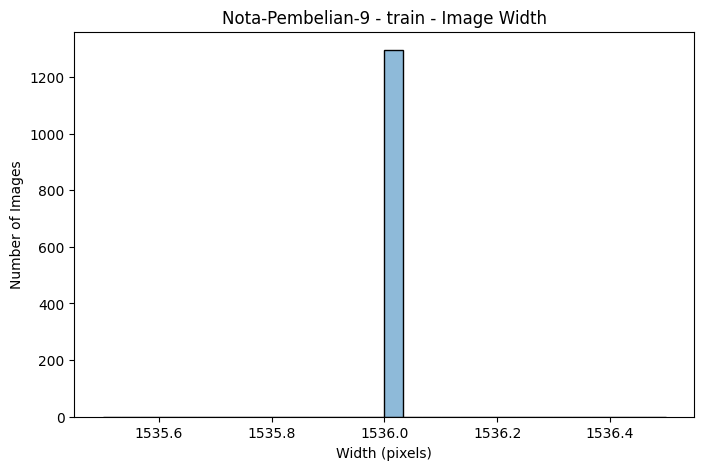

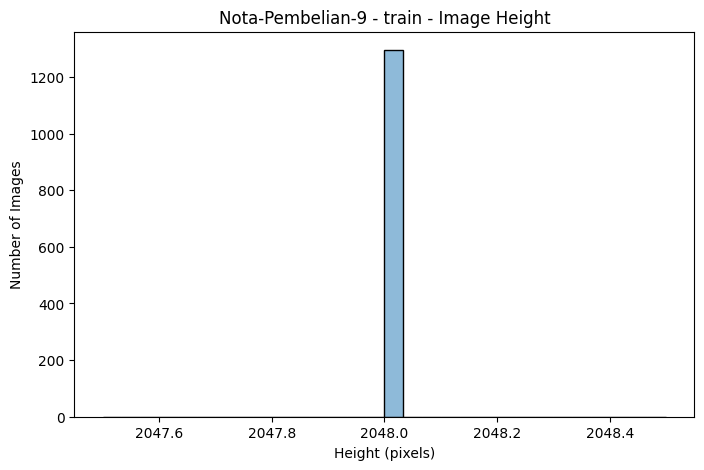

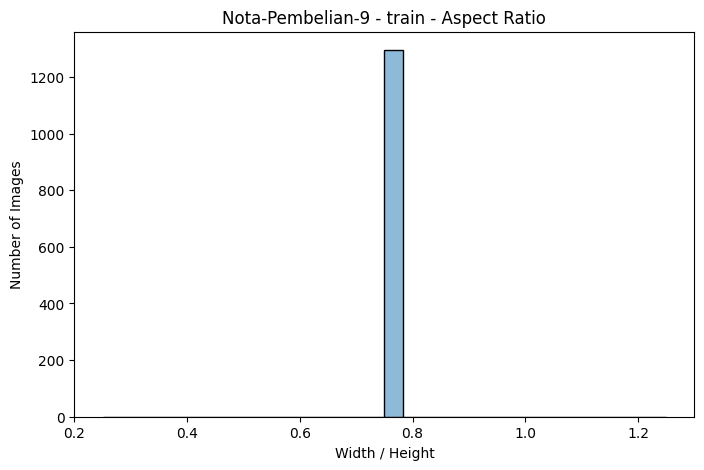

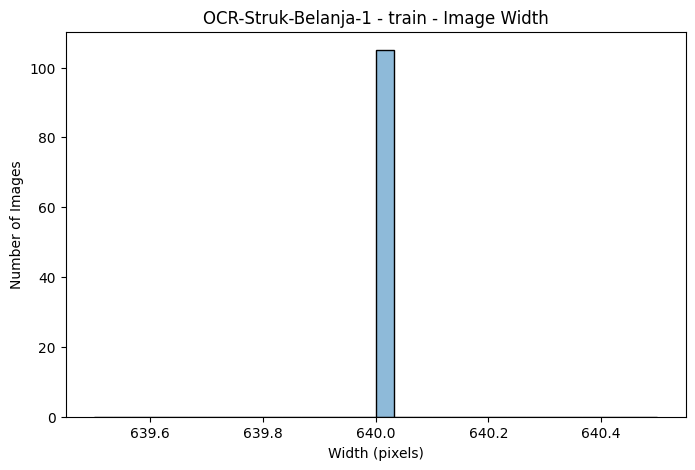

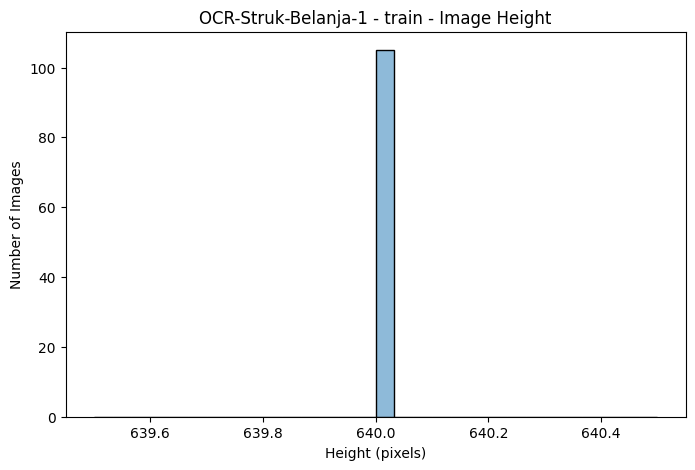

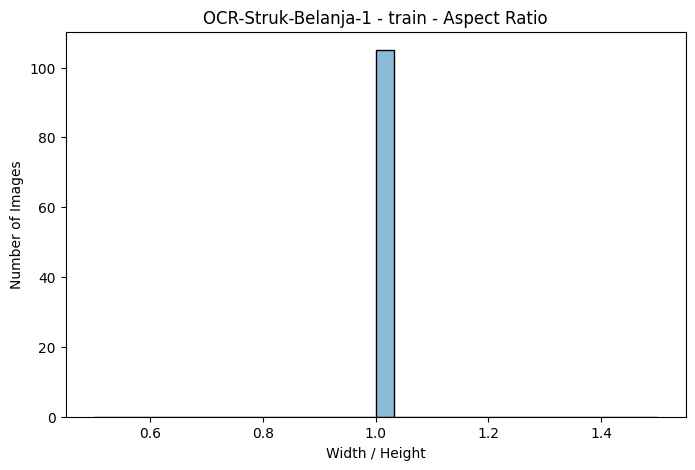

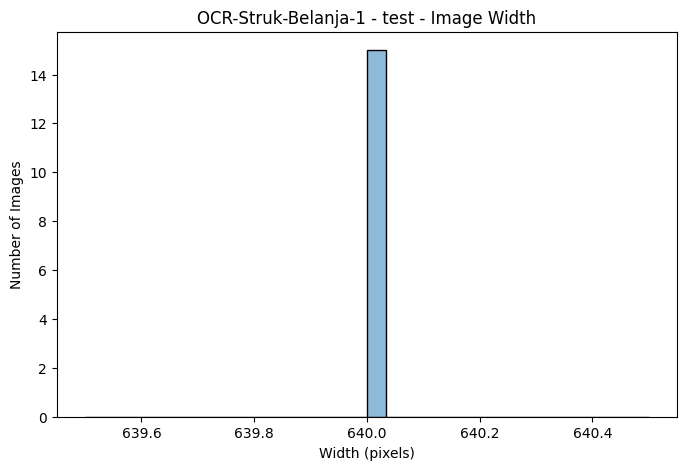

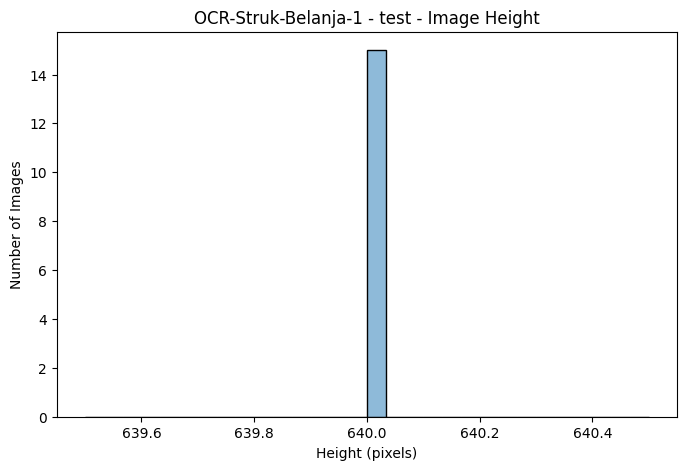

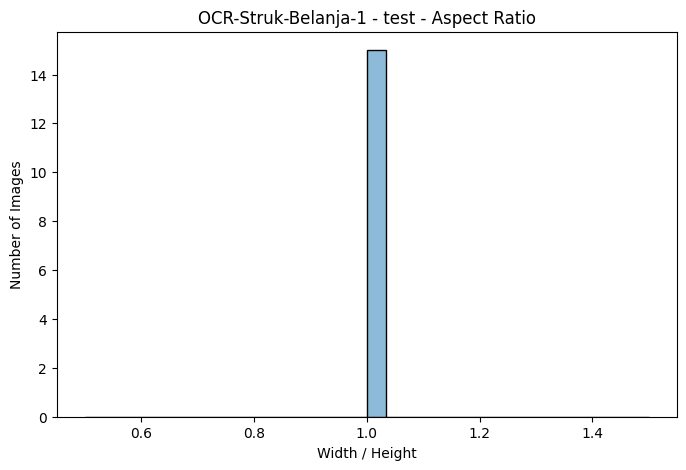

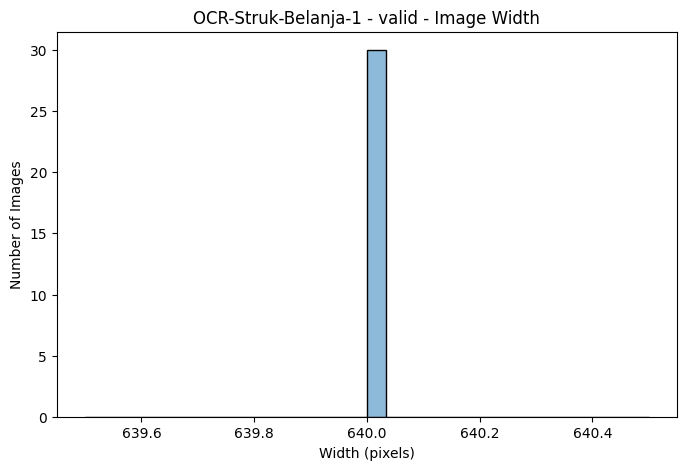

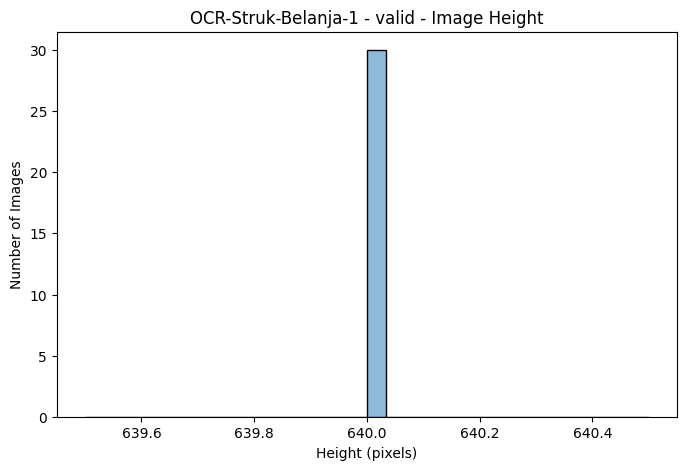

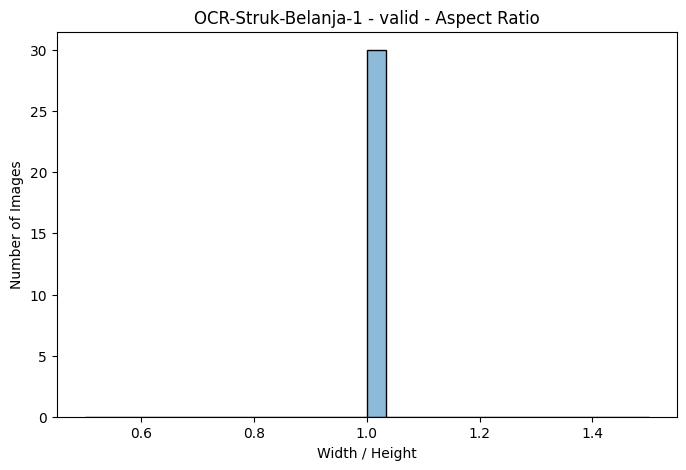

In [ ]:
for dataset_name, splits in dataset_dfs.items():

    for split, dfs in splits.items():

        images_df = dfs["images"].copy()

        if images_df.empty:
            continue

        images_df["aspect_ratio"] = (
            images_df["width"] /
            images_df["height"]
        )

        plt.figure(figsize=(8, 5))
        sns.histplot(
            images_df["width"],
            bins=30,
            kde=True
        )
        plt.title(f"{dataset_name} - {split} - Image Width")
        plt.xlabel("Width (pixels)")
        plt.ylabel("Number of Images")
        plt.show()

        plt.figure(figsize=(8, 5))
        sns.histplot(
            images_df["height"],
            bins=30,
            kde=True
        )
        plt.title(f"{dataset_name} - {split} - Image Height")
        plt.xlabel("Height (pixels)")
        plt.ylabel("Number of Images")
        plt.show()

        plt.figure(figsize=(8, 5))
        sns.histplot(
            images_df["aspect_ratio"],
            bins=30,
            kde=True
        )
        plt.title(f"{dataset_name} - {split} - Aspect Ratio")
        plt.xlabel("Width / Height")
        plt.ylabel("Number of Images")
        plt.show()

In [ ]:
for dataset_name, splits in dataset_dfs.items():

    for split, dfs in splits.items():

        annotations_df = dfs["annotations"].copy()

        if annotations_df.empty:
            continue

        print("\n")
        print("=" * 80)
        print(f"{dataset_name} - {split.upper()} - BOUNDING BOXES")
        print("=" * 80)

        bbox_values = pd.DataFrame(
            annotations_df["bbox"].tolist(),
            columns=[
                "bbox_x",
                "bbox_y",
                "bbox_width",
                "bbox_height"
            ],
            index=annotations_df.index
        )

        annotations_df = pd.concat(
            [annotations_df, bbox_values],
            axis=1
        )

        annotations_df["bbox_area"] = (
            annotations_df["bbox_width"] *
            annotations_df["bbox_height"]
        )

        display(
            annotations_df[
                [
                    "bbox_x",
                    "bbox_y",
                    "bbox_width",
                    "bbox_height",
                    "bbox_area"
                ]
            ].describe()
        )

        dataset_dfs[dataset_name][split]["annotations"] = annotations_df



Nota-Pembelian-9 - TRAIN - BOUNDING BOXES


,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area
count,18585.000000,18585.000000,18585.000000,18585.000000,18585.000000
mean,676.648430,675.618190,171.169477,75.650451,12976.082361
std,378.251895,278.855362,63.603236,4.110070,4964.700907
min,59.500000,345.030000,24.960000,52.570000,1461.446000
25%,361.570000,533.320000,120.950000,73.090000,9091.630600
50%,618.730000,607.740000,176.080000,75.500000,13209.806400
75%,1110.920000,697.480000,211.640000,78.550000,16202.820000
max,1232.600000,1723.340000,420.700000,87.630000,32159.268400




OCR-Struk-Belanja-1 - TRAIN - BOUNDING BOXES


,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area
count,420.000000,420.000000,420.000000,420.000000,420.000000
mean,104.364286,195.880952,425.302381,214.594048,105574.316667
std,76.616630,174.091546,129.382636,229.366066,129727.639535
min,0.000000,0.000000,151.500000,14.000000,2534.000000
25%,47.000000,27.750000,319.375000,49.750000,18694.375000
50%,95.000000,159.500000,433.250000,101.750000,37681.750000
75%,146.000000,329.750000,534.625000,331.000000,158904.750000
max,385.000000,592.000000,640.000000,640.000000,409600.000000




OCR-Struk-Belanja-1 - TEST - BOUNDING BOXES


,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,116.016667,180.683333,390.166667,205.508333,94315.829167
std,72.887536,156.315575,114.942199,226.767250,120622.119176
min,2.000000,0.000000,148.000000,15.500000,2294.000000
25%,67.750000,39.750000,318.625000,49.000000,16685.250000
50%,105.000000,157.000000,414.000000,90.500000,32422.375000
75%,138.250000,297.500000,454.000000,323.500000,133628.625000
max,348.000000,595.000000,613.000000,640.000000,388480.000000




OCR-Struk-Belanja-1 - VALID - BOUNDING BOXES


,bbox_x,bbox_y,bbox_width,bbox_height,bbox_area
count,120.000000,120.000000,120.000000,120.000000,120.000000
mean,104.208333,196.283333,425.287500,212.795833,105920.460417
std,70.981699,177.467629,129.082715,231.170764,132115.807817
min,0.000000,0.000000,172.000000,23.500000,4935.000000
25%,52.000000,33.750000,332.000000,44.750000,17373.750000
50%,96.500000,176.000000,425.250000,97.250000,38258.125000
75%,153.000000,311.000000,523.250000,329.000000,134205.187500
max,337.000000,610.000000,640.000000,640.000000,409600.000000


In [ ]:
bbox_quality_results = []

for dataset_name, splits in dataset_dfs.items():

    for split, dfs in splits.items():

        ann = dfs["annotations"].copy()
        img = dfs["images"].copy()

        if ann.empty:
            continue

        check = ann.merge(
            img[["id", "width", "height"]],
            left_on="image_id",
            right_on="id",
            suffixes=("_annotation", "_image")
        )

        check["x2"] = (
            check["bbox_x"] +
            check["bbox_width"]
        )

        check["y2"] = (
            check["bbox_y"] +
            check["bbox_height"]
        )

        invalid_width = check[
            check["bbox_width"] <= 0
        ]

        invalid_height = check[
            check["bbox_height"] <= 0
        ]

        negative_x = check[
            check["bbox_x"] < 0
        ]

        negative_y = check[
            check["bbox_y"] < 0
        ]

        out_right = check[
            check["x2"] > check["width"]
        ]

        out_bottom = check[
            check["y2"] > check["height"]
        ]

        bbox_quality_results.append({
            "dataset": dataset_name,
            "split": split,
            "annotations": len(check),
            "invalid_width": len(invalid_width),
            "invalid_height": len(invalid_height),
            "negative_x": len(negative_x),
            "negative_y": len(negative_y),
            "out_right": len(out_right),
            "out_bottom": len(out_bottom)
        })

bbox_quality_df = pd.DataFrame(
    bbox_quality_results
)

display(bbox_quality_df)

,dataset,split,annotations,invalid_width,invalid_height,negative_x,negative_y,out_right,out_bottom
0,Nota-Pembelian-9,train,18585,0,0,0,0,0,0
1,OCR-Struk-Belanja-1,train,420,0,0,0,0,0,0
2,OCR-Struk-Belanja-1,test,60,0,0,0,0,0,0
3,OCR-Struk-Belanja-1,valid,120,0,0,0,0,0,0




CLASS DISTRIBUTION: Nota-Pembelian-9

--- TRAIN ---


,class,count
0,1,921
1,2,612
2,5,408
3,es,395
4,2000,392
...,...,...
733,670000,2
734,539000,2
735,sambel,2
736,instal,2


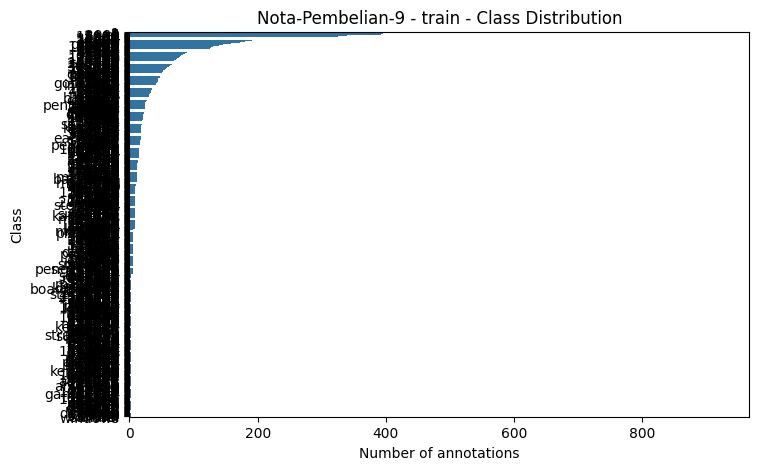



CLASS DISTRIBUTION: OCR-Struk-Belanja-1

--- TRAIN ---


,class,count
0,total,106
1,struk_belanja,105
2,item_belanja,105
3,info_toko,104


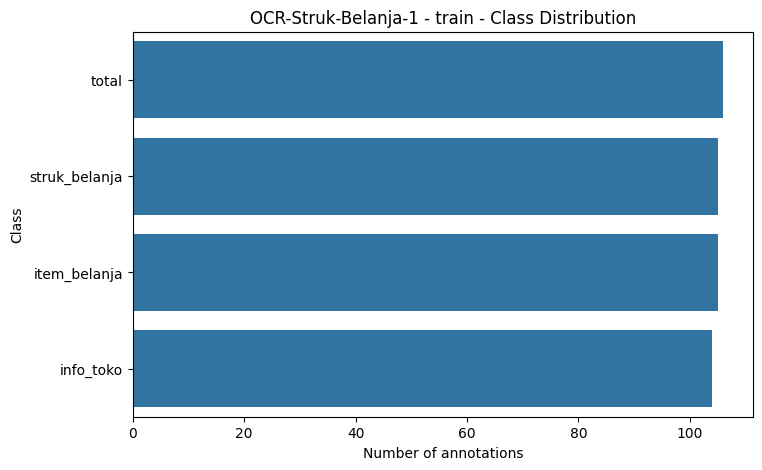


--- TEST ---


,class,count
0,struk_belanja,15
1,info_toko,15
2,item_belanja,15
3,total,15


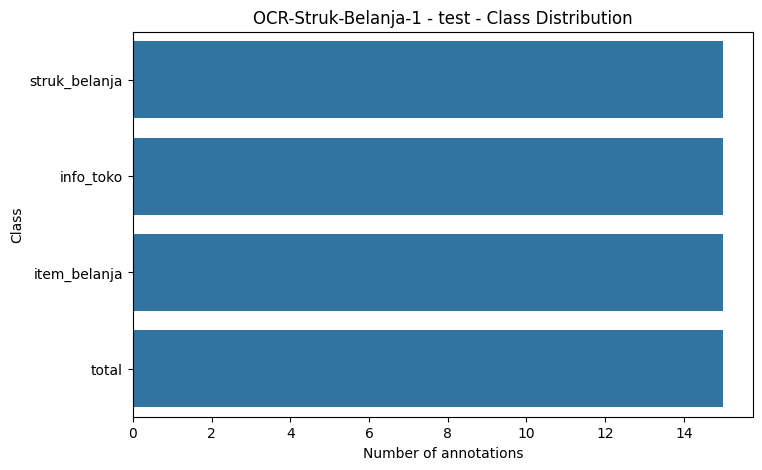


--- VALID ---


,class,count
0,info_toko,31
1,struk_belanja,30
2,item_belanja,30
3,total,29


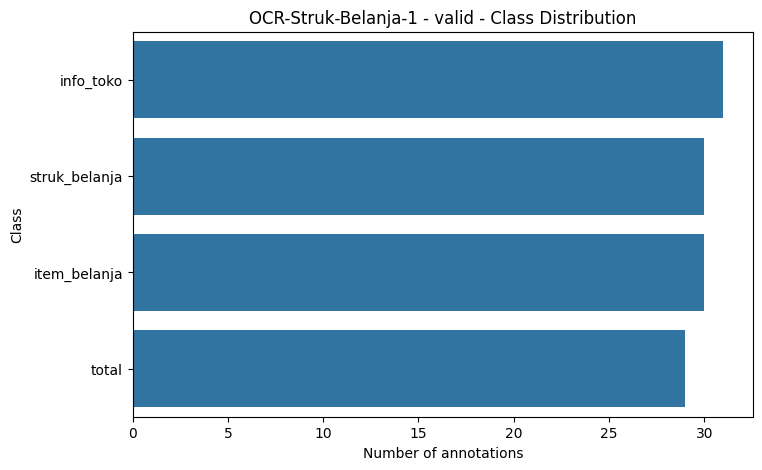

In [ ]:
for dataset_name, splits in coco_data.items():

    print("\n")
    print("=" * 80)
    print(f"CLASS DISTRIBUTION: {dataset_name}")
    print("=" * 80)

    first_split = next(iter(splits))
    data = splits[first_split]

    categories = {
        cat["id"]: cat["name"]
        for cat in data["categories"]
    }

    for split, dfs in dataset_dfs[dataset_name].items():

        ann = dfs["annotations"].copy()

        if ann.empty:
            continue

        ann["class_name"] = (
            ann["category_id"]
            .map(categories)
        )

        print(f"\n--- {split.upper()} ---")

        display(
            ann["class_name"]
            .value_counts()
            .rename_axis("class")
            .reset_index(name="count")
        )

        plt.figure(figsize=(8, 5))

        sns.countplot(
            data=ann,
            y="class_name",
            order=ann["class_name"].value_counts().index
        )

        plt.title(
            f"{dataset_name} - {split} - Class Distribution"
        )

        plt.xlabel("Number of annotations")
        plt.ylabel("Class")

        plt.show()

In [ ]:
for dataset_name, splits in coco_data.items():
    print("\n" + "="*80)
    print(dataset_name)
    print("="*80)

    for split, data in splits.items():
        print(f"\n{split.upper()}")

        for category in data["categories"]:
            print(
                f"{category['id']:4d} : "
                f"{category['name']}"
            )


Nota-Pembelian-9

TRAIN
   0 : objects
   1 : 1
 101 : 2
 163 : 3
 209 : 4
 239 : 5
 269 : 6
 293 : 7
 307 : 8
 320 : 9
   2 : 10
  18 : 11
  31 : 12
  44 : 13
  53 : 14
  62 : 15
  72 : 16
  78 : 17
  85 : 18
 102 : 20
 132 : 24
 137 : 25
 164 : 30
 176 : 32
 240 : 50
 270 : 60
 294 : 70
   3 : 100
 103 : 200
 138 : 250
 165 : 300
 241 : 500
   4 : 1000
  32 : 1200
  63 : 1500
  86 : 1800
 104 : 2000
 112 : 2100
 118 : 2200
 127 : 2300
 133 : 2400
 139 : 2500
 166 : 3000
 185 : 3500
 210 : 4000
 228 : 4500
 242 : 5000
 257 : 5500
 271 : 6000
 284 : 6500
 295 : 7000
 302 : 7500
 308 : 8000
 313 : 8500
 321 : 9000
 325 : 9500
   5 : 10000
  19 : 11000
  33 : 12000
  37 : 12500
  45 : 13000
  49 : 13500
  54 : 14000
  64 : 15000
  73 : 16000
  79 : 17000
  87 : 18000
  91 : 18500
  94 : 19000
 105 : 20000
 113 : 21000
 119 : 22000
 123 : 22500
 128 : 23000
 134 : 24000
 140 : 25000
 147 : 26000
 151 : 27000
 154 : 27500
 157 : 28000
 161 : 29000
 167 : 30000
 172 : 31000
 174 : 31500
 1

In [ ]:
# Inspect 10 annotations from each dataset

for dataset_name, splits in coco_data.items():

    print("\n")
    print("=" * 100)
    print(dataset_name)
    print("=" * 100)

    for split, data in splits.items():

        print(f"\n--- {split.upper()} ---")

        categories = {
            c["id"]: c["name"]
            for c in data["categories"]
        }

        for ann in data["annotations"][:10]:

            print({
                "image_id": ann["image_id"],
                "category_id": ann["category_id"],
                "category": categories.get(
                    ann["category_id"]
                ),
                "bbox": ann["bbox"],
                "area": ann["area"],
                "segmentation": ann["segmentation"][:1]
                    if ann.get("segmentation")
                    else None
            })



Nota-Pembelian-9

--- TRAIN ---
{'image_id': 0, 'category_id': 164, 'category': '30', 'bbox': [117.59, 469.22, 129.89, 75.27], 'area': 9776.82, 'segmentation': None}
{'image_id': 0, 'category_id': 102, 'category': '20', 'bbox': [107.18, 558.62, 131.62, 77.36], 'area': 10182.123, 'segmentation': None}
{'image_id': 0, 'category_id': 416, 'category': 'cucur', 'bbox': [329.36, 460.11, 299.56, 78.32], 'area': 23461.539, 'segmentation': None}
{'image_id': 0, 'category_id': 631, 'category': 'putu', 'bbox': [325.88, 550.37, 227.52, 82.54], 'area': 18779.501, 'segmentation': None}
{'image_id': 0, 'category_id': 345, 'category': 'ayu', 'bbox': [555.43, 549.07, 182.69, 83.85], 'area': 15318.556, 'segmentation': None}
{'image_id': 0, 'category_id': 104, 'category': '2000', 'bbox': [960.87, 454.75, 203.48, 84.01], 'area': 17094.355, 'segmentation': None}
{'image_id': 0, 'category_id': 139, 'category': '2500', 'bbox': [961.3, 548.46, 202.19, 83.92], 'area': 16967.785, 'segmentation': None}
{'image

In [ ]:
data = coco_data["Nota-Pembelian-9"]["train"]

categories_df = pd.DataFrame(data["categories"])

print("=" * 80)
print("NOTA-PEMBELIAN-9 VOCABULARY ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

texts = categories_df["name"].astype(str)

print("\nNumber of unique categories:")
print(len(texts))

print("\nFirst 100 categories:")
print(texts.head(100).tolist())


# ------------------------------------------------------------
# Text length
# ------------------------------------------------------------

text_length = texts.str.len()

print("\n" + "=" * 80)
print("TEXT LENGTH")
print("=" * 80)

print(text_length.describe())


# ------------------------------------------------------------
# Numeric-only
# ------------------------------------------------------------

numeric_only = texts.str.fullmatch(r"\d+")

print("\nNumeric-only categories:")
print(numeric_only.sum())

print(
    f"Percentage: "
    f"{numeric_only.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# Alphabetic-only
# ------------------------------------------------------------

alphabetic_only = texts.str.fullmatch(
    r"[A-Za-z]+"
)

print("\nAlphabetic-only categories:")
print(alphabetic_only.sum())

print(
    f"Percentage: "
    f"{alphabetic_only.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# Alphanumeric
# ------------------------------------------------------------

alphanumeric = texts.str.fullmatch(
    r"[A-Za-z0-9]+"
)

print("\nAlphanumeric categories:")
print(alphanumeric.sum())


# ------------------------------------------------------------
# Contains spaces
# ------------------------------------------------------------

contains_space = texts.str.contains(
    r"\s",
    regex=True
)

print("\nCategories containing spaces:")
print(contains_space.sum())

if contains_space.sum() > 0:

    print(
        texts[contains_space]
        .head(50)
        .tolist()
    )


# ------------------------------------------------------------
# Contains punctuation
# ------------------------------------------------------------

contains_punctuation = texts.str.contains(
    r"[^A-Za-z0-9\s]",
    regex=True
)

print("\nCategories containing punctuation:")
print(contains_punctuation.sum())

if contains_punctuation.sum() > 0:

    print(
        texts[contains_punctuation]
        .head(50)
        .tolist()
    )


# ------------------------------------------------------------
# Character vocabulary
# ------------------------------------------------------------

all_text = "".join(texts.tolist())

characters = sorted(
    set(all_text)
)

print("\n" + "=" * 80)
print("CHARACTER VOCABULARY")
print("=" * 80)

print("Number of unique characters:")
print(len(characters))

print("\nCharacters:")
print(characters)


# ------------------------------------------------------------
# Annotation count per category
# ------------------------------------------------------------

annotations_df = pd.DataFrame(
    data["annotations"]
)

category_counts = (
    annotations_df["category_id"]
    .value_counts()
    .rename_axis("category_id")
    .reset_index(name="annotation_count")
)

category_counts = category_counts.merge(
    categories_df[["id", "name"]],
    left_on="category_id",
    right_on="id"
)

category_counts = category_counts[
    [
        "category_id",
        "name",
        "annotation_count"
    ]
].sort_values(
    "annotation_count",
    ascending=False
)

print("\n" + "=" * 80)
print("MOST FREQUENT TRANSCRIPTIONS")
print("=" * 80)

display(
    category_counts.head(50)
)


# ------------------------------------------------------------
# Rare categories
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RARE TRANSCRIPTIONS")
print("=" * 80)

display(
    category_counts[
        category_counts["annotation_count"] <= 2
    ].head(100)
)

NOTA-PEMBELIAN-9 VOCABULARY ANALYSIS

Number of unique categories:
739

First 100 categories:
['objects', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '20', '24', '25', '30', '32', '50', '60', '70', '100', '200', '250', '300', '500', '1000', '1200', '1500', '1800', '2000', '2100', '2200', '2300', '2400', '2500', '3000', '3500', '4000', '4500', '5000', '5500', '6000', '6500', '7000', '7500', '8000', '8500', '9000', '9500', '10000', '11000', '12000', '12500', '13000', '13500', '14000', '15000', '16000', '17000', '18000', '18500', '19000', '20000', '21000', '22000', '22500', '23000', '24000', '25000', '26000', '27000', '27500', '28000', '29000', '30000', '31000', '31500', '32000', '33000', '34000', '34500', '35000', '35500', '36000', '37000', '37500', '38000', '39000', '39500', '40000', '40500', '42000', '42500']

TEXT LENGTH
count    739.000000
mean       5.207037
std        1.454515
min        1.000000
25%        4.000000
50%        

,category_id,name,annotation_count
0,1,1,921
1,101,2,612
2,239,5,408
3,433,es,395
4,104,2000,392
5,163,3,392
6,64,15000,350
7,242,5000,339
8,2,10,338
9,209,4,325



RARE TRANSCRIPTIONS


,category_id,name,annotation_count
723,51,136500,2
724,658,selai,2
725,174,31500,2
726,498,kaos,2
727,493,kaki,2
728,422,dalaman,2
729,468,hijab,2
730,551,manset,2
731,476,instan,2
732,328,98000,2


# Modeling

In [ ]:
import os
import json
import random
import shutil
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = Path("/content")

NOTA_DIR = BASE_DIR / "Nota-Pembelian-9"
NOTA_TRAIN_DIR = NOTA_DIR / "train"

COCO_PATH = NOTA_TRAIN_DIR / "_annotations.coco.json"

OUTPUT_DIR = BASE_DIR / "nota_recognition"

TRAIN_DIR = OUTPUT_DIR / "train"
VAL_DIR = OUTPUT_DIR / "val"
TEST_DIR = OUTPUT_DIR / "test"

for directory in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/content/nota_recognition


In [ ]:
with open(COCO_PATH, "r") as f:
    coco = json.load(f)

images = {
    img["id"]: img
    for img in coco["images"]
}

categories = {
    cat["id"]: cat["name"]
    for cat in coco["categories"]
}

annotations = coco["annotations"]

print("Images:", len(images))
print("Annotations:", len(annotations))
print("Categories:", len(categories))

Images: 1295
Annotations: 18585
Categories: 739


In [ ]:
image_ids = list(images.keys())

train_ids, temp_ids = train_test_split(
    image_ids,
    test_size=0.20,
    random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

train_ids = set(train_ids)
val_ids = set(val_ids)
test_ids = set(test_ids)

print("Train images:", len(train_ids))
print("Validation images:", len(val_ids))
print("Test images:", len(test_ids))

print(
    "Total:",
    len(train_ids) +
    len(val_ids) +
    len(test_ids)
)

Train images: 1036
Validation images: 129
Test images: 130
Total: 1295


In [ ]:
def crop_with_padding(
    image,
    bbox,
    padding_ratio=0.05
):
    """
    COCO bbox:
    [x, y, width, height]
    """

    x, y, w, h = bbox

    pad_x = w * padding_ratio
    pad_y = h * padding_ratio

    left = max(
        0,
        int(x - pad_x)
    )

    top = max(
        0,
        int(y - pad_y)
    )

    right = min(
        image.width,
        int(x + w + pad_x)
    )

    bottom = min(
        image.height,
        int(y + h + pad_y)
    )

    return image.crop(
        (left, top, right, bottom)
    )

In [ ]:
split_map = {
    "train": train_ids,
    "val": val_ids,
    "test": test_ids
}

records = {
    "train": [],
    "val": [],
    "test": []
}

counters = {
    "train": 0,
    "val": 0,
    "test": 0
}

for ann in annotations:

    image_id = ann["image_id"]

    if image_id not in images:
        continue

    # Determine split
    split = None

    for split_name, ids in split_map.items():

        if image_id in ids:
            split = split_name
            break

    if split is None:
        continue

    image_info = images[image_id]

    image_path = (
        NOTA_TRAIN_DIR /
        image_info["file_name"]
    )

    if not image_path.exists():
        print(
            "Missing:",
            image_path
        )
        continue

    transcription = categories.get(
        ann["category_id"]
    )

    if transcription is None:
        continue

    transcription = str(
        transcription
    ).strip()

    if transcription == "":
        continue

    try:

        image = Image.open(
            image_path
        ).convert("RGB")

        crop = crop_with_padding(
            image,
            ann["bbox"],
            padding_ratio=0.05
        )

        # Skip obviously invalid crops
        if crop.width < 2 or crop.height < 2:
            continue

        crop_id = counters[split]

        output_name = (
            f"{image_id}_{ann['id']}_{crop_id}.jpg"
        )

        output_path = (
            OUTPUT_DIR /
            split /
            output_name
        )

        crop.save(
            output_path,
            quality=95
        )

        records[split].append({
            "image": output_name,
            "transcription": transcription,
            "source_image_id": image_id,
            "source_annotation_id": ann["id"],
            "width": crop.width,
            "height": crop.height
        })

        counters[split] += 1

    except Exception as e:

        print(
            f"Error processing "
            f"{image_path}: {e}"
        )

print("\nGenerated crops:")

for split in records:
    print(
        split,
        ":",
        len(records[split])
    )


Generated crops:
train : 14970
val : 1793
test : 1822


In [ ]:
for split in records:

    label_path = (
        OUTPUT_DIR /
        f"{split}_rec.txt"
    )

    with open(
        label_path,
        "w",
        encoding="utf-8"
    ) as f:

        for record in records[split]:

            image_path = (
                f"{split}/"
                f"{record['image']}"
            )

            f.write(
                f"{image_path}\t"
                f"{record['transcription']}\n"
            )

    print(
        f"Saved: {label_path}"
    )

Saved: /content/nota_recognition/train_rec.txt
Saved: /content/nota_recognition/val_rec.txt
Saved: /content/nota_recognition/test_rec.txt
